# Imports

In [1]:
import pandas as pd
import numpy as np
from multiprocessing import Pool
import random
import re
from defs import bfs_dfs_search

# Import combinations from itertools
from itertools import combinations
from itertools import permutations

import os
from zgli.folder import Folder

import graphviz
from IPython.display import Image

#### 0. Genereate example distance matrix

In [2]:
data_path = '0.example_data'                          # Define data path to the folther containing the files
compressor = 'bzlib'                                  # Define the compressor to be used
output_path = '1.example_dms'                         # Define output path for distance_matrix.txt
folder = Folder(data_path)                            # Initialize Folder class
dm = folder.distance_matrix(compressor, output_path = '1.example_dms/' )  # Compute distances

Compressing Files...


  0%|          | 0/10 [00:00<?, ?it/s]

Compressing Appended Files...


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

0_mouse.txt 0.0 0.941648 0.964551 0.967002 0.957282 0.960252 0.960088 0.967124 0.960965 0.965251
0_rat.txt 0.941648 0.0 0.966302 0.96132 0.958167 0.958732 0.966924 0.960157 0.955044 0.958172
1_graySeal.txt 0.964551 0.966302 0.0 0.77382 0.96105 0.959818 0.954923 0.964729 0.949891 0.942299
1_harborSeal.txt 0.967002 0.96132 0.77382 0.0 0.960009 0.960252 0.953671 0.962769 0.947334 0.94423
2_blueWhale.txt 0.957282 0.958167 0.96105 0.960009 0.0 0.955691 0.854465 0.960157 0.949342 0.95903
2_chimpanzee.txt 0.960252 0.958732 0.959818 0.960252 0.955691 0.0 0.953301 0.8649 0.949175 0.961604
2_finWhale.txt 0.960088 0.966924 0.954923 0.953671 0.854465 0.953301 0.0 0.956238 0.948465 0.958172
2_human.txt 0.967124 0.960157 0.964729 0.962769 0.960157 0.8649 0.956238 0.0 0.95123 0.959459
4_horse.txt 0.960965 0.955044 0.949891 0.947334 0.949342 0.949175 0.948465 0.95123 0.0 0.952166
5_cat.txt 0.965251 0.958172 0.942299 0.94423 0.95903 0.961604 0.958172 0.959459 0.952166 0.0



#### 1. Read distance matrix

In [3]:
dm_path = '1.example_dms/distmatrix.txt' 

data = np.loadtxt(dm_path, delimiter = ".txt",dtype=str)
labels = data.T[0]
dm = data.T[1:].T
new_dm = []
for i in dm:
    i[0].split(' ')
    new_dm.append(i[0].split(' ')[1:])

dm = np.array(new_dm).astype(float)

print(dm)
print(labels)

[[0.       0.941648 0.964551 0.967002 0.957282 0.960252 0.960088 0.967124
  0.960965 0.965251]
 [0.941648 0.       0.966302 0.96132  0.958167 0.958732 0.966924 0.960157
  0.955044 0.958172]
 [0.964551 0.966302 0.       0.77382  0.96105  0.959818 0.954923 0.964729
  0.949891 0.942299]
 [0.967002 0.96132  0.77382  0.       0.960009 0.960252 0.953671 0.962769
  0.947334 0.94423 ]
 [0.957282 0.958167 0.96105  0.960009 0.       0.955691 0.854465 0.960157
  0.949342 0.95903 ]
 [0.960252 0.958732 0.959818 0.960252 0.955691 0.       0.953301 0.8649
  0.949175 0.961604]
 [0.960088 0.966924 0.954923 0.953671 0.854465 0.953301 0.       0.956238
  0.948465 0.958172]
 [0.967124 0.960157 0.964729 0.962769 0.960157 0.8649   0.956238 0.
  0.95123  0.959459]
 [0.960965 0.955044 0.949891 0.947334 0.949342 0.949175 0.948465 0.95123
  0.       0.952166]
 [0.965251 0.958172 0.942299 0.94423  0.95903  0.961604 0.958172 0.959459
  0.952166 0.      ]]
['0_mouse' '0_rat' '1_graySeal' '1_harborSeal' '2_blueWhal

#### 2. Generate Random Tree

In [4]:
def generate_random_tree(leaf_labels):
    
    """
        Generates a random tree from leaf_labels.

        Parameters
        ----------
        df : array_like
            A list with the labels of the objects to be put in a trenary tree structure.

        Returns
        -------
        tree_dict : dict
            A dictionary containing all the inner tree nodes and its connections to other inner nodes/ leafs.

        Notes
        --------
        Function returns error if leafs are less than 6.
    """
    
    if len(leaf_labels) < 6:
        raise Exception("There must be at least six objects to cluster.")
    
    inner_node_labels = np.array([])
    tree_dict = {}

    # Initialize inner nodes
    for n in range(0,len(leaf_labels)-2):
        inner_node_labels = np.append(inner_node_labels, ('n' + str(n)))

    # Tree dict
    for n in inner_node_labels:
        tree_dict[n] = np.array([])

    # print(f'leaf_lables: {leaf_labels}')
    # print(f'inner_node_labels: {inner_node_labels}')
    # print(f'tree_dict: {tree_dict}')

    # Create inner_node connections
    nodes_to_use = inner_node_labels.copy()
    for index,node in enumerate(inner_node_labels):

        if len(nodes_to_use) == 0:
            break

        if node in nodes_to_use:
            index = np.argwhere(nodes_to_use == node)
            nodes_to_use = np.delete(nodes_to_use, index)

        # Initialize root node
        if index == 0:

            # Roll for number of inner_node connections
            possible_rolls = np.arange(1,4)
            number_of_connections = np.random.choice(possible_rolls)

            # Create number of connections rolled
            for connection in range(number_of_connections):
                node_to_connect = nodes_to_use[0]
                nodes_to_use = np.delete(nodes_to_use, 0)
                tree_dict[node] = np.append(tree_dict[node], node_to_connect)
                tree_dict[node_to_connect] = np.append(tree_dict[node_to_connect], node)

        elif index != 0 and len(tree_dict[node]) < 3:

            # Roll for number of inner_node connection
            possible_rolls = np.arange(1,4-len(tree_dict[node]))
            number_of_connections = np.random.choice(possible_rolls)

            if number_of_connections > len(nodes_to_use):
                number_of_connections = len(nodes_to_use)

            # Create number of connections rolled
            for connection in range(number_of_connections):
                node_to_connect = nodes_to_use[0]
                nodes_to_use = np.delete(nodes_to_use, 0)
                tree_dict[node] = np.append(tree_dict[node], node_to_connect)
                tree_dict[node_to_connect] = np.append(tree_dict[node_to_connect], node)

    # Add leafs to inner_nodes
    for node in tree_dict.keys():

        number_of_leafs = range(3 - len(tree_dict[node]))

        for n in number_of_leafs:
            leaf = np.random.choice(leaf_labels,1)
            leaf_index = np.where(leaf_labels == leaf)
            leaf_labels = np.delete(leaf_labels,leaf_index)
            tree_dict[node] = np.append(tree_dict[node], leaf)
            
        
            
    return tree_dict

In [5]:
# leaf_labels = labels
leaf_labels = ['a','b','c','d','e','f','g','h']
tree_dict = generate_random_tree(leaf_labels)
tree_dict

{'n0': array(['n1', 'n2', 'g'], dtype='<U32'),
 'n1': array(['n0', 'n3', 'n4'], dtype='<U32'),
 'n2': array(['n0', 'n5', 'f'], dtype='<U32'),
 'n3': array(['n1', 'h', 'd'], dtype='<U32'),
 'n4': array(['n1', 'a', 'c'], dtype='<U32'),
 'n5': array(['n2', 'e', 'b'], dtype='<U32')}

#### 3. Leaf Swap

In [6]:
def select_two_random_nodes_with_leafs(tree_dict):
    
    """
        Selects two random inner nodes.

        Parameters
        ----------
        tree_dict : dict
            A dictionary containing all the inner tree nodes and its connections to other inner nodes/ leafs.

        Returns
        -------
        random_nodes : array_like
            A list with the names of two random inner nodes.
        
    """
    # Get list of nodes
    nodes = np.array(list(tree_dict.keys()))
    
    # Regex for: starts with "n" and the next 1-5 characters are digits from 0-9
    pattern = "^[n][0-9]{1,5}$"
    
    # Initialize random nodes
    first_random_node = None
    second_random_node = None
    
    # Initialize leaf arrays
    leaf_indexes_1 = np.array([])
    leaf_indexes_2 = np.array([])
    
    # Search for first node with leafs
    while len(leaf_indexes_1) == 0:
        first_random_node = np.random.choice(nodes,1)
        for i,node in enumerate(tree_dict[first_random_node[0]]):
            if not re.match(pattern, node):
                leaf_indexes_1 = np.append(leaf_indexes_1,i)
                
    # Remove first random node from the options
    index = np.argwhere(nodes == first_random_node)
    nodes = np.delete(nodes, index)
    
    # Search for second node with leafs
    while len(leaf_indexes_2) == 0:
        second_random_node = np.random.choice(nodes,1)
        for i,node in enumerate(tree_dict[second_random_node[0]]):
            if not re.match(pattern, node):
                leaf_indexes_2 = np.append(leaf_indexes_2,i)
            
    
    return {first_random_node[0]: leaf_indexes_1, second_random_node[0]: leaf_indexes_2}

In [7]:
select_two_random_nodes_with_leafs(tree_dict)

{'n4': array([1., 2.]), 'n0': array([2.])}

In [8]:
def leaf_swap(tree_dict):
    
    """
        Swap two leaf labels of given tree.

        Parameters
        ----------
        tree_dict : dict
            A dictionary with all the inner nodes and their respective connections.

        Returns
        -------
        tree_dict : dict
            A dictionary containing all the inner tree nodes and its connections to other inner nodes/ leafs, with two random leafs swaped.

        Notes
        --------
        Random mother nodes can be connected.
    """
    
    # Select two random unconnected inner nodes
    random_nodes = select_two_random_nodes_with_leafs(tree_dict)
    
    # Select two random leafs to switch
    nodes = list(random_nodes.keys())
    print(f'nodes:{nodes}')
    random_leaf_1 = np.random.choice(random_nodes[nodes[0]])
    random_leaf_2 = np.random.choice(random_nodes[nodes[1]])
    print(tree_dict[nodes[0]][int(random_leaf_1)], tree_dict[nodes[1]][int(random_leaf_2)])
    
    # Save leaf values
    leaf_1_val = tree_dict[nodes[0]][int(random_leaf_1)]
    leaf_2_val = tree_dict[nodes[1]][int(random_leaf_2)]
    
    # Switch leaf values
    tree_dict[nodes[0]][int(random_leaf_1)] = leaf_2_val
    tree_dict[nodes[1]][int(random_leaf_2)] = leaf_1_val
    
    return tree_dict

leaf_swap(tree_dict)

nodes:['n2', 'n5']
f e


{'n0': array(['n1', 'n2', 'g'], dtype='<U32'),
 'n1': array(['n0', 'n3', 'n4'], dtype='<U32'),
 'n2': array(['n0', 'n5', 'e'], dtype='<U32'),
 'n3': array(['n1', 'h', 'd'], dtype='<U32'),
 'n4': array(['n1', 'a', 'c'], dtype='<U32'),
 'n5': array(['n2', 'f', 'b'], dtype='<U32')}

#### 4. Swap inner nodes

In [9]:
def select_two_unconected_nodes(tree_dict):
    
    """
        Selects two random (unconnected) inner nodes.

        Parameters
        ----------
        tree_dict : dict
            A dictionary containing all the inner tree nodes and its connections to other inner nodes/ leafs.

        Returns
        -------
        random_nodes : array_like
            A list with the names of two radom unconnected inner nodes.

    """
    
    # Select a random node
    nodes = list(tree_dict.keys())
    first_random_node = np.random.choice(nodes,1)
    
    # Remove random node and its connections from pool of nodes before choosing another
    nodes_to_remove = np.append([first_random_node[0]],tree_dict[first_random_node[0]])
    new_nodes = np.array([])
    
    # Create new node list containing only unconnected nodes
    for node in nodes:
        if node not in nodes_to_remove:
            new_nodes = np.append(new_nodes,node)
    
    # Select seccond random node
    second_random_node = np.random.choice(new_nodes,1)
    
    return [first_random_node, second_random_node]

In [10]:
def swap_inner_nodes(tree_dict):
    
    """
        Swap two inner nodes.

        Parameters
        ----------
        tree_dict : dict
            A dictionary with all the inner nodes and their respective connections.

        Returns
        -------
        tree_dict : dict
            A dictionary containing all the inner tree nodes and its connections to other inner nodes/ leafs, with two random inner nodes swapped.

        Notes
        --------
        Random mother nodes can be connected, but swapped connection is never the same as the one that connects both nodes. Meaning, if n1 is
        connected to n2, the connection chosen will never be n1 <-> n2, with the algorythm always seaching for n1 <-> not n2.
        
     """
    
    # Initialize nodes
    nodes = list(tree_dict.keys())

    # Find two nodes with swapable inner connections
    find_nodes = True
    random_nodes = None
    while find_nodes:

        # Choose two random nodes
        random_nodes = np.random.choice(nodes,2,replace=False)
        # print(f'random nodes:{random_nodes}')

        # Check if nodes are connected and remove connection if there is any
        nodes_zero = np.array(tree_dict[random_nodes[0]])
        nodes_one = np.array(tree_dict[random_nodes[1]])

        if random_nodes[1] in tree_dict[random_nodes[0]]:
            # print('yep')
            index = np.argwhere(nodes_zero == random_nodes[1])
            nodes_zero = np.delete(nodes_zero, index)

            index = np.argwhere(nodes_one == random_nodes[0])
            nodes_one = np.delete(nodes_one, index)

        # Regex for: starts with "n" and the next 1-5 characters are digits from 0-9
        pattern = "^[n][0-9]{1,5}$"

        # Check if there are any inner connection
        inner_connections_zero = []
        inner_connections_one = []

        # Node one
        for node in nodes_zero:
            if re.match(pattern, node):
                inner_connections_zero.append(node)

        # Node two
        for node in nodes_one:
            if re.match(pattern, node):
                inner_connections_one.append(node)

        # Remove common connection

        # Node zero
        new_nodes_zero = []
        for node in inner_connections_zero:
             if node not in inner_connections_one:
                new_nodes_zero.append(node)

        # Node one
        new_nodes_one = []
        for node in inner_connections_one:
             if node not in inner_connections_zero:
                new_nodes_one.append(node)

        if len(new_nodes_zero) > 0 and len(new_nodes_one) > 0:
            find_nodes = False

    # Select nodes to swap
    choices = [np.random.choice(new_nodes_zero,1), np.random.choice(new_nodes_one,1)]

    # print(choices[0], choices[1])

    # Swap inner connections
    index = np.argwhere(tree_dict[random_nodes[0]] == choices[0][0])
    tree_dict[random_nodes[0]][index] = choices[1][0]

    index = np.argwhere(tree_dict[choices[0][0]] == random_nodes[0])
    tree_dict[choices[0][0]][index] = random_nodes[1]

    index = np.argwhere(tree_dict[random_nodes[1]] == choices[1][0])
    tree_dict[random_nodes[1]][index] = choices[0][0]

    index = np.argwhere(tree_dict[choices[1][0]] == random_nodes[1])
    tree_dict[choices[1][0]][index] = random_nodes[0]

    return tree_dict


In [11]:
swap_inner_nodes(tree_dict)

{'n0': array(['n5', 'n2', 'g'], dtype='<U32'),
 'n1': array(['n2', 'n3', 'n4'], dtype='<U32'),
 'n2': array(['n0', 'n1', 'e'], dtype='<U32'),
 'n3': array(['n1', 'h', 'd'], dtype='<U32'),
 'n4': array(['n1', 'a', 'c'], dtype='<U32'),
 'n5': array(['n0', 'f', 'b'], dtype='<U32')}

In [12]:
def Checker(reader):
    return np.unique(reader).size != reader.size

In [13]:
error = False
for i in range(1000):
    swap_inner_nodes(tree_dict)
    for k,v in tree_dict.items():
        if Checker(v) == True:
            error = True

print(error)

False


#### 5. Swap Node with leaf

In [64]:
def swap_node_with_leaf(tree_dict):
    
    """
        Swap node with leaf.

        Parameters
        ----------
        tree_dict : dict
            A dictionary with all the inner nodes and their respective connections.

        Returns
        -------
        tree_dict : dict
            A dictionary containing all the inner tree nodes and its connections to other inner nodes/ leafs, with a leaf and a node swapped.

        Notes
        --------
        Leaf node must have at least 1 leaf, since one is needed for the swapping process. Inner node must have at least 2 inner connections since
        the node recieving a leaf always needs to keep one inner connection to remain connected to the tree.
    """
    
    # Initialize nodes
    nodes = list(tree_dict.keys())
    
    # Regex for: starts with "n" and the next 1-5 characters are digits from 0-9
    pattern = "^[n][0-9]{1,5}$"
    
    # Select node with at least one leaf
    leaf_node = None
    leafs = np.array([])
    
    # Search for first node with leafs
    while len(leafs) == 0:
        leaf_node = np.random.choice(nodes,1)
        for node in tree_dict[leaf_node[0]]:
            if not re.match(pattern, node):
                leafs = np.append(leafs, node)
    
    # Remove first random node from the options
    index = np.argwhere(nodes == leaf_node)
    nodes = np.delete(nodes, index)
    
    # Search for inner node
    inner_node = None
    inner_connections = np.array([])
    
    # Search for node with inner connections > 0. If len == 0 it means connectios where removed during filtering and we need a new node

        
    # Search for node with at least 2 inner connections
    while len(inner_connections) < 2:
        inner_node = np.random.choice(nodes,1)
        inner_connections = np.array([])
        for node in tree_dict[inner_node[0]]:
            if re.match(pattern, node):
                inner_connections = np.append(inner_connections, node)

    # Remove connection between nodes, if there is any
    index = np.argwhere(inner_connections  == leaf_node)
    if len(index) > 0:
        inner_connections = np.delete(inner_connections, index)

    # Remove common connection between leaf node and inner node. EX: LeafNode:n1 | InnerNode:n3 | n1 <-> n2 <-> n3 | Common connectio: n2
    common_connection = np.intersect1d(tree_dict[inner_node[0]], tree_dict[leaf_node[0]])
    print(common_connection)
    if len(common_connection) > 0:
        print(f'Im in: common_connection: {common_connection}')
        index = np.argwhere(inner_connections  == common_connection[0])
        inner_connections = np.delete(inner_connections, index)
    
    print(f'leaf_node: {leaf_node} \t leafs: {leafs}')
    print(f'inner_node: {inner_node} \t inner_connections: {inner_connections}')
    
    random_leaf = np.random.choice(leafs,1)
    random_inner_node = np.random.choice(inner_connections,1)
    
    print(f'random_leaf: {random_leaf}')
    print(f'random_inner_node : {random_inner_node}')
    
    index = np.argwhere(tree_dict[leaf_node[0]] == random_leaf)
    tree_dict[leaf_node[0]][index] = random_inner_node
    
    index = np.argwhere(tree_dict[random_inner_node[0]] == inner_node)
    tree_dict[random_inner_node[0]][index] = leaf_node
    
    index = np.argwhere(tree_dict[inner_node[0]] == random_inner_node)
    tree_dict[inner_node[0]][index] = random_leaf
    
    return tree_dict


In [65]:
a = np.array([])

while len(a) < 1:
    print('len <1')
    
    a = np.append(a,1)
    
    while len(a) < 2:
        print('len < 2')
        
        a = np.append(a,1)

len <1
len < 2


In [66]:
swap_node_with_leaf(tree_dict)

[]
leaf_node: ['n5'] 	 leafs: ['d' 'b']
inner_node: ['n2'] 	 inner_connections: ['n0']
random_leaf: ['b']
random_inner_node : ['n0']


{'n0': array(['n1', 'n5', 'n3'], dtype='<U32'),
 'n1': array(['n0', 'n4', 'c'], dtype='<U32'),
 'n2': array(['b', 'n5', 'g'], dtype='<U32'),
 'n3': array(['n0', 'f', 'a'], dtype='<U32'),
 'n4': array(['n1', 'e', 'h'], dtype='<U32'),
 'n5': array(['n2', 'd', 'n0'], dtype='<U32')}

#### 6. Generate leaf pairs and all_quartets

In [16]:
def generate_leaf_pairs(leaf_labels):
    
    return tuple(combinations(leaf_labels, 2))

def generate_all_quartets(leaf_labels):
    
    leaf_quartets = combinations(leaf_labels, 4)
    all_quartets = []
    for quartet in leaf_quartets:
        c = tuple(combinations(quartet, 2))
        all_quartets.append((c[0],c[5]))
        all_quartets.append((c[1],c[4]))
        all_quartets.append((c[2],c[3]))
        
    return all_quartets

leaf_pairs = generate_leaf_pairs(leaf_labels)
all_quartets = generate_all_quartets(leaf_labels)

#### 7. Generate leaf dict with the mother nodes for all the leafs

In [17]:
def generate_leaf_dict(tree_dict):
    
    # Regex for: starts with "n" and the next 1-5 characters are digits from 0-9
    pattern = "^[n][0-9]{1,5}$"

    leaf_dict = {}
    for k,v in tree_dict.items():

        for node in v:
            if not re.match(pattern, node):
                    leaf_dict[node] = np.array([k])
    
    return leaf_dict
                
leaf_dict = generate_leaf_dict(tree_dict)

In [18]:
tree_dict | leaf_dict 

{'n0': array(['n1', 'f', 'g'], dtype='<U32'),
 'n1': array(['n5', 'n0', 'n2'], dtype='<U32'),
 'n2': array(['n1', 'n5', 'e'], dtype='<U32'),
 'n3': array(['n4', 'h', 'd'], dtype='<U32'),
 'n4': array(['n3', 'a', 'c'], dtype='<U32'),
 'n5': array(['n1', 'n2', 'b'], dtype='<U32'),
 'f': array(['n0'], dtype='<U2'),
 'g': array(['n0'], dtype='<U2'),
 'e': array(['n2'], dtype='<U2'),
 'h': array(['n3'], dtype='<U2'),
 'd': array(['n3'], dtype='<U2'),
 'a': array(['n4'], dtype='<U2'),
 'c': array(['n4'], dtype='<U2'),
 'b': array(['n5'], dtype='<U2')}

#### 8. Search Alogrithm

In [19]:
# bfs_dfs_search([tree_dict | leaf_dict ,'2_blueWhale','1_harborSeal',0])

In [20]:
bfs_dfs_search([tree_dict | leaf_dict ,'a','h',0])

Searching from a to h


['n4', 'n3']

#### 8. Find all paths to all leaf_paris

In [21]:
graph = tree_dict | leaf_dict

def get_leaf_pairs_with_paths(leaf_pairs, graph, processes):
    
    # Create Arguments for search function
    argument_list = [[graph, pair[0], pair[1], 1] for pair in leaf_pairs]
    p = Pool()
    paths = p.map(bfs_dfs_search,argument_list)
    p.close()
    p.join()
    
    # Initialize dictionary with leaf pairs and their respective paths
    leaf_pairs_with_paths = {}
    for i,pair in enumerate(leaf_pairs):
        leaf_pairs_with_paths[pair] = paths[i]
    
    return leaf_pairs_with_paths
    
    

In [22]:
leaf_pairs_with_paths = get_leaf_pairs_with_paths(leaf_pairs, tree_dict | leaf_dict, 5)

#### Find all consistent quartets

In [23]:
def find_consistent_quartets(all_quartets, leaf_pairs_with_paths):
    
    consistent_quartets = []
    for quartet in all_quartets:

        # Define quartets
        pair_one = tuple(quartet[0])
        pair_two = tuple(quartet[1])
        # print(f'pair_one:{pair_one}, pair_two:{pair_two}')

        # Get quartet Paths
        # print(f'pair_one_path: {leaf_pairs_with_paths[pair_one]}, pair_two_path: {leaf_pairs_with_paths[pair_two]},')
        # pair_one_path = leaf_pairs_with_paths[pair]

        # Check if paths do not intercept
        if len(np.intersect1d(np.array(leaf_pairs_with_paths[pair_one]), leaf_pairs_with_paths[pair_two])) == 0:
            consistent_quartets.append(quartet)
            
    return consistent_quartets

In [24]:
consistent_quartets = find_consistent_quartets(all_quartets, leaf_pairs_with_paths)

#### 9. Compute tree cost

In [25]:
def compute_quartet_cost(dm, labels,quartet):
    pair_one = np.array(quartet[0])
    pair_two = np.array(quartet[1])
    
    pair_one_i = [np.argwhere(labels == node)[0][0] for node in pair_one]
    pair_two_i = [np.argwhere(labels == node)[0][0] for node in pair_two]

    cost_one = dm[pair_one_i[0]][pair_one_i[1]]
    cost_two = dm[pair_two_i[0]][pair_two_i[1]]
    
    return cost_one + cost_two

In [26]:
def compute_min_max_tree_costs(all_quartets):
    min_tree_cost = 0
    max_tree_cost = 0 

    for three_quartets in np.array(all_quartets).reshape(int(len(all_quartets)/3),3,2,2):
        costs = []
        for quartet in three_quartets:
            costs.append(compute_quartet_cost(dm,labels,quartet))
        min_tree_cost += min(costs)
        max_tree_cost += max(costs)
        
    return min_tree_cost, max_tree_cost

In [27]:
min_tree_cost, max_tree_cost = compute_min_max_tree_costs(all_quartets)
print(f'min_tree_cost = {min_tree_cost}, max_tree_cost = {max_tree_cost}')

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
def compute_tree_cost(consistent_quartets, dm, labels, min_tree_cost, max_tree_cost):
    cost = 0
    for quartet in consistent_quartets:
        cost += compute_quartet_cost(dm, labels,quartet)

    return cost
    # return (max_tree_cost - cost) / (max_tree_cost - min_tree_cost)

In [ ]:
compute_tree_cost(consistent_quartets, dm, labels, min_tree_cost, max_tree_cost)

#### 10. Genetic algorithm
**Stopage conditions:**
1. Score did not change for 4 iterations
2. Search time over X time
3. Score reached 0.99

#### Vizualize tree

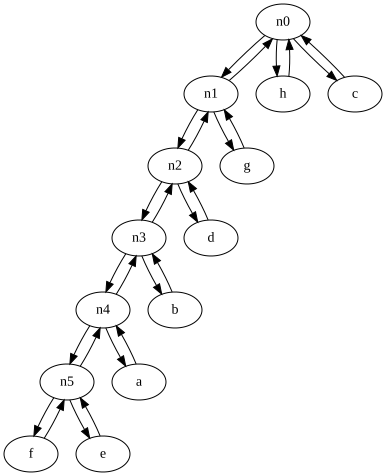

In [92]:
# Labels and random tree
leaf_labels = ['a','b','c','d','e','f','g','h']
tree_dict = generate_random_tree(leaf_labels)
leaf_dict = generate_leaf_dict(tree_dict)
graph = tree_dict | leaf_dict

dot = graphviz.Digraph('round-table', comment='The Round Table')  

for key,values in graph.items():
    dot.node(key,key)
    for v in values:
        dot.edge(key,v)

dot.render(directory='doctest-output').replace('\\', '/')
dot

[]
leaf_node: ['n5'] 	 leafs: ['f' 'e']
inner_node: ['n1'] 	 inner_connections: ['n0' 'n2']
random_leaf: ['f']
random_inner_node : ['n2']


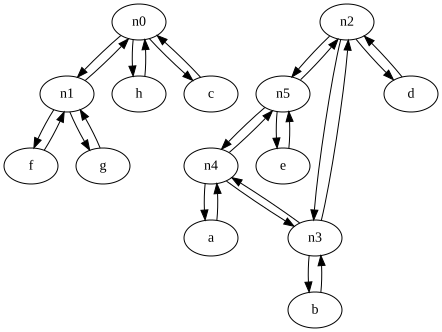

In [93]:
# Swap and make graph
tree_dict = swap_node_with_leaf(tree_dict)
leaf_dict = generate_leaf_dict(tree_dict)
graph = tree_dict | leaf_dict

dot = graphviz.Digraph('round-table', comment='The Round Table')  

for key,values in graph.items():
    dot.node(key,key)
    for v in values:
        dot.edge(key,v)

dot.render(directory='doctest-output').replace('\\', '/')
dot

In [72]:
tree_dict

{'n0': array(['n1', 'n2', 'd'], dtype='<U32'),
 'n1': array(['n0', 'a', 'c'], dtype='<U32'),
 'n2': array(['n0', 'n4', 'n5'], dtype='<U32'),
 'n3': array(['n5', 'b', 'e'], dtype='<U32'),
 'n4': array(['n2', 'f', 'h'], dtype='<U32'),
 'n5': array(['n2', 'n3', 'g'], dtype='<U32')}